# Data Analysis 2: Assignment 2 - Amsterdam Hotels Analysis

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [15]:
hotels_europe_price = pd.read_csv("https://osf.io/p6tyr/download")
hotels_europe_features = pd.read_csv("https://osf.io/utwjs/download")

In [16]:
hotels_europe_features.head()

,hotel_id,city,distance,stars,rating,country,city_actual,rating_reviewcount,center1label,center2label,neighbourhood,ratingta,ratingta_count,distance_alter,accommodation_type
0,1,Amsterdam,3.1,4.0,4.3,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,Amsterdam,4.0,1115.0,3.6,Hotel
1,2,Amsterdam,0.9,2.0,4.1,Netherlands,Amsterdam,372.0,City centre,Montelbaanstoren,Amsterdam,4.0,999.0,0.8,Hostel
2,3,Amsterdam,1.5,4.0,4.1,Netherlands,Amsterdam,165.0,City centre,Montelbaanstoren,Amsterdam,4.0,674.0,1.4,Hotel
3,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,Amsterdam,3.5,1882.0,2.1,Hotel
4,5,Amsterdam,1.8,3.5,4.0,Netherlands,Amsterdam,4.0,City centre,Montelbaanstoren,Amsterdam,4.5,66.0,2.0,Hotel


In [17]:
# -Filtering and cleaning the data-

city_choice = "Amsterdam"

f = hotels_europe_features.copy()

# keeping only chosen city
f = f[f["city"].astype(str).str.lower() == city_choice.lower()].copy()

# basic validity filters (defensible / minimal)
f = f.dropna(subset=["hotel_id", "rating", "stars", "distance"]).copy()
# results give 424 unique hotel IDs (>/250 hotels), making Amsterdam and it's hotels available for the analysis

# keeping plausible ranges
f = f[(f["rating"].between(0, 5)) &
      (f["stars"].between(0, 5)) &
      (f["distance"] >= 0)].copy()

# optional: removing the hotels with 0 reviews to get the best values for the ratings
if "rating_reviewcount" in f.columns:
    f = f[f["rating_reviewcount"].fillna(0) > 0].copy()

# remove duplicates (one row per hotel)
f = f.sort_values(["hotel_id"]).drop_duplicates(subset=["hotel_id"], keep="first")

print("City:", city_choice)
print("N hotels after filtering:", f["hotel_id"].nunique())
f[["distance", "stars", "rating"]].describe()


City: Amsterdam
N hotels after filtering: 424


,distance,stars,rating
count,424.000000,424.000000,424.000000
mean,1.621934,3.142689,3.806132
std,2.004125,0.933507,0.665112
min,0.100000,1.000000,1.000000
25%,0.500000,2.500000,3.500000
50%,1.000000,3.000000,4.000000
75%,1.700000,4.000000,4.300000
max,12.000000,5.000000,5.000000


In [18]:
p = hotels_europe_price.copy()

# checking that the columns exist (useful if merge errors happen)
display(p.head())
print("price columns:", list(p.columns))
print("features columns:", list(f.columns))


,hotel_id,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room
0,1,172,0,0% no offer,2017,11,1,0,1,0
1,1,122,1,15-50% offer,2018,1,1,0,1,0
2,1,122,1,15-50% offer,2017,12,0,1,1,0
3,1,552,1,1-15% offer,2017,12,0,1,4,0
4,1,122,1,15-50% offer,2018,2,1,0,1,0


price columns: ['hotel_id', 'price', 'offer', 'offer_cat', 'year', 'month', 'weekend', 'holiday', 'nnights', 'scarce_room']
features columns: ['hotel_id', 'city', 'distance', 'stars', 'rating', 'country', 'city_actual', 'rating_reviewcount', 'center1label', 'center2label', 'neighbourhood', 'ratingta', 'ratingta_count', 'distance_alter', 'accommodation_type']


In [19]:
# merging on key: "hotel_id", and creating the new dataframe that will be used through the work
if "hotel_id" in p.columns:
    p = p.dropna(subset=["hotel_id"]).copy()
    p = p.sort_values(["hotel_id"]).drop_duplicates(subset=["hotel_id"], keep="first")

    df = pd.merge(f, p, on="hotel_id", how="inner")
else:
    # fallback: merge on common columns (rare, but just in case)
    common = sorted(list(set(f.columns).intersection(set(p.columns))))
    print("No hotel_id in prices; common columns:", common)
    df = pd.merge(f, p, on=common, how="inner")

print("Merged rows:", len(df))
print("Unique hotels merged:", df["hotel_id"].nunique())
df.head()

Merged rows: 424
Unique hotels merged: 424


,hotel_id,city,distance,stars,rating,country,city_actual,rating_reviewcount,center1label,center2label,...,accommodation_type,price,offer,offer_cat,year,month,weekend,holiday,nnights,scarce_room
0,1,Amsterdam,3.1,4.0,4.3,Netherlands,Amsterdam,1030.0,City centre,Montelbaanstoren,...,Hotel,172,0,0% no offer,2017,11,1,0,1,0
1,2,Amsterdam,0.9,2.0,4.1,Netherlands,Amsterdam,372.0,City centre,Montelbaanstoren,...,Hostel,119,0,0% no offer,2017,11,0,0,1,0
2,3,Amsterdam,1.5,4.0,4.1,Netherlands,Amsterdam,165.0,City centre,Montelbaanstoren,...,Hotel,737,1,1-15% offer,2017,12,0,1,4,0
3,4,Amsterdam,1.9,3.0,3.5,Netherlands,Amsterdam,298.0,City centre,Montelbaanstoren,...,Hotel,115,1,15-50% offer,2017,12,0,1,1,0
4,5,Amsterdam,1.8,3.5,4.0,Netherlands,Amsterdam,4.0,City centre,Montelbaanstoren,...,Hotel,690,1,15-50% offer,2017,11,0,0,1,1


##### Creating the highly rated column

In [20]:
df["highly_rated"] = (df["rating"] >= 4).astype(int)

df["highly_rated"].value_counts(dropna=False), df["highly_rated"].mean()


(highly_rated
 1    217
 0    207
 Name: count, dtype: int64,
 np.float64(0.5117924528301887))

#### Quick descriptives before the regression

In [ ]:
# keeping only the columns we need for the core models
df_model = df[["highly_rated", "distance", "stars"]].dropna().copy()

print("N:", len(df_model))
print("Highly rated share:", df_model["highly_rated"].mean())

df_model.describe()


N: 424
Highly rated share: 0.5117924528301887


,highly_rated,distance,stars
count,424.000000,424.000000,424.000000
mean,0.511792,1.621934,3.142689
std,0.500451,2.004125,0.933507
min,0.000000,0.100000,1.000000
25%,0.000000,0.500000,2.500000
50%,1.000000,1.000000,3.000000
75%,1.000000,1.700000,4.000000
max,1.000000,12.000000,5.000000


In [22]:
# Comparing means by rating group
df_model.groupby("highly_rated")[["distance", "stars"]].agg(["mean", "std", "count"])

distance                     stars                
                  mean       std count      mean       std count
highly_rated                                                    
0             1.319807  1.593934   207  2.647343  0.841162   207
1             1.910138  2.296029   217  3.615207  0.756514   217

In [23]:
# Share highly rated by star level (stars are in 0.5 increments)
star_table = (df_model
              .groupby("stars")["highly_rated"]
              .agg(rate="mean", n="size")
              .reset_index()
              .sort_values("stars"))

star_table

,stars,rate,n
0,1.0,0.052632,19
1,1.5,0.000000,4
2,2.0,0.164179,67
3,2.5,0.222222,18
4,3.0,0.448276,145
5,3.5,0.758621,29
6,4.0,0.769231,117
7,4.5,0.500000,2
8,5.0,1.000000,23


## Estimating the 3 models: LPM, Logit, Probit

In [ ]:
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col # to crate a table for the results that includes all three models so it becomes easy to compare their results

X = sm.add_constant(df_model[["distance", "stars"]])
y = df_model["highly_rated"]

# 1) LPM (OLS) with robust SEs
lpm = sm.OLS(y, X).fit(cov_type="HC1")

# 2) Logit
logit = sm.Logit(y, X).fit(disp=False)

# 3) Probit
probit = sm.Probit(y, X).fit(disp=False)

summary_col(
    results=[lpm, logit, probit],
    model_names=["LPM (OLS)", "Logit", "Probit"],
    stars=True,
    info_dict={
        "N": lambda m: f"{int(m.nobs)}",
        "Pseudo R2 / R2": lambda m: f"{m.prsquared:.3f}" if hasattr(m, "prsquared") else f"{m.rsquared:.3f}"
    }
)


,LPM (OLS),Logit,Probit
const,-0.3735***,-4.7928***,-2.8396***
,(0.0568),(0.5345),(0.2924)
distance,0.0179*,0.0830,0.0482
,(0.0102),(0.0605),(0.0350)
stars,0.2724***,1.4919***,0.8856***
,(0.0169),(0.1651),(0.0904)
R-squared,0.2743,,
R-squared Adj.,0.2708,,
N,424,424,424
Pseudo R2 / R2,0.274,0.229,0.229


### Marginal Effects for logit/probit interpretation

In [26]:
# LPM marginal effects are just the coefficients
print("LPM coefficients (probability units):")
print(lpm.params)

# AMEs for logit & probit
me_logit = logit.get_margeff(at="overall")   # AME
me_probit = probit.get_margeff(at="overall") # AME

print("\nLogit AME:")
print(me_logit.summary())

print("\nProbit AME:")
print(me_probit.summary())


LPM coefficients (probability units):
const      -0.373495
distance    0.017941
stars       0.272438
dtype: float64

Logit AME:
        Logit Marginal Effects       
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
distance       0.0149      0.011      1.382      0.167      -0.006       0.036
stars          0.2677      0.017     15.481      0.000       0.234       0.302

Probit AME:
       Probit Marginal Effects       
Dep. Variable:           highly_rated
Method:                          dydx
At:                           overall
                dy/dx    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
distance       0.0146      0.011      1.385      0.166      -0.006       0.035
st

## Predicted probabilities + Graph 1

In [27]:
# setting a distance grid within the sample range
d_min, d_max = df_model["distance"].quantile([0.01, 0.99])
dist_grid = np.linspace(d_min, d_max, 60)

# choosing a few representative star levels present in the data
star_levels = sorted(df_model["stars"].dropna().unique())
# common choice: 2,3,4,5 if present; otherwise quantiles
candidate = [2.0, 3.0, 4.0, 5.0]
stars_to_plot = [s for s in candidate if s in star_levels]
if len(stars_to_plot) == 0:
    stars_to_plot = [star_levels[0], star_levels[len(star_levels)//2], star_levels[-1]]

pred_rows = []
for s in stars_to_plot:
    tmp = pd.DataFrame({"const": 1.0, "distance": dist_grid, "stars": s})
    tmp["stars_level"] = s
    tmp["p_lpm"] = lpm.predict(tmp[["const", "distance", "stars"]])
    tmp["p_logit"] = logit.predict(tmp[["const", "distance", "stars"]])
    tmp["p_probit"] = probit.predict(tmp[["const", "distance", "stars"]])
    pred_rows.append(tmp)

pred = pd.concat(pred_rows, ignore_index=True)
pred.head()


,const,distance,stars,stars_level,p_lpm,p_logit,p_probit
0,1.0,0.100000,2.0,2.0,0.173175,0.141756,0.143738
1,1.0,0.260627,2.0,2.0,0.176057,0.143385,0.145500
2,1.0,0.421254,2.0,2.0,0.178939,0.145031,0.147276
3,1.0,0.581881,2.0,2.0,0.181821,0.146691,0.149067
4,1.0,0.742508,2.0,2.0,0.184703,0.148368,0.150873


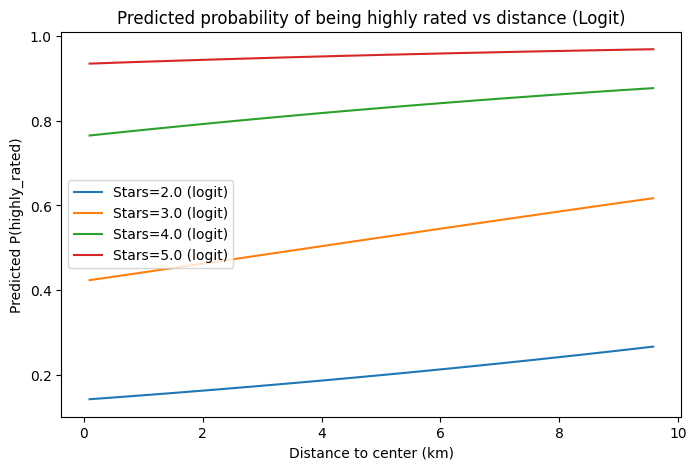

In [28]:
# Plotting the predicted probabilities vs distance (Logit by default)
plt.figure(figsize=(8,5))
for s in stars_to_plot:
    sub = pred[pred["stars_level"] == s]
    plt.plot(sub["distance"], sub["p_logit"], label=f"Stars={s} (logit)")
plt.xlabel("Distance to center (km)")
plt.ylabel("Predicted P(highly_rated)")
plt.title("Predicted probability of being highly rated vs distance (Logit)")
plt.legend()
plt.show()


#### Graph 2: simple and useful for comparison between the data in the dataset

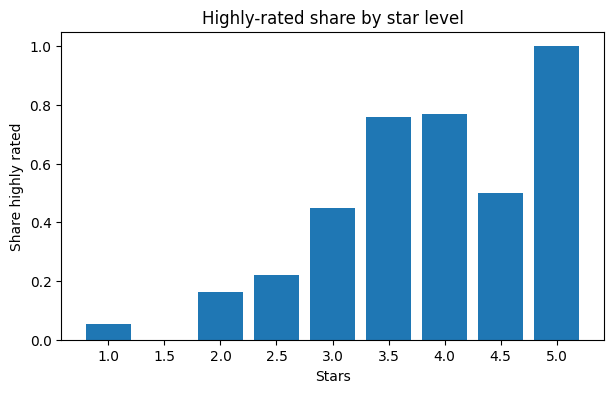

In [29]:
# bar chart: share highly rated by stars
plt.figure(figsize=(7,4))
plt.bar(star_table["stars"].astype(str), star_table["rate"])
plt.xlabel("Stars")
plt.ylabel("Share highly rated")
plt.title("Highly-rated share by star level")
plt.show()
